# 1. Preparando los datos

## 1.1 Examinamos los datos

In [67]:
import pandas as pd 

#Extraemos los datos de los archivos csv
df_train = pd.read_csv("gold_recovery_train.csv")
df_train.name = "Entrenamiento"
df_test = pd.read_csv("gold_recovery_test.csv")
df_test.name = "Prueba"
df_full = pd.read_csv("gold_recovery_full.csv")
df_full.name = "Completo"

#una lista de los data frames es util para validaciones posteriores
df = [df_train, df_test, df_full]

#definimos una función para imprimir la forma, informacion, estadisticas descriptivas, primeras filas y numero de valores unicos de cada data frame
def lookup_data(data_f):
    #imprimimos la forma, informacion, estadisticas descriptivas, primeras filas y numero de valores unicos de cada data frame
    print(f'Forma del data frame {data_f.name}: \n {data_f.shape}')
    print(f'Estadísticas descriptivas del data frame {data_f.name}: \n {data_f.describe(include="all")}')
    print(f'Primeras filas del data frame {data_f.name}: \n {data_f.head()}')
    print(f'Número de valores únicos del data frame {data_f.name}: \n {data_f.nunique()}')
    #convertimos la fecha en el tipo de datos correcto
    data_f['date'] = pd.to_datetime(data_f['date'], format='%Y-%m-%d %H:%M:%S')

#aplicamos la función a cada data frame
for frame in df:
    lookup_data(frame)


Forma del data frame Entrenamiento: 
 (16860, 87)
Estadísticas descriptivas del data frame Entrenamiento: 
                        date  final.output.concentrate_ag  \
count                 16860                 16788.000000   
unique                16860                          NaN   
top     2016-01-15 00:00:00                          NaN   
freq                      1                          NaN   
mean                    NaN                     4.716907   
std                     NaN                     2.096718   
min                     NaN                     0.000000   
25%                     NaN                     3.971262   
50%                     NaN                     4.869346   
75%                     NaN                     5.821176   
max                     NaN                    16.001945   

        final.output.concentrate_pb  final.output.concentrate_sol  \
count                  16788.000000                  16490.000000   
unique                          N

Vemos que hay ceros en algunas columnas en todos los dataframes y valores nulos

## 1.2 Verificamos el calculo de recuperacion

In [68]:
import numpy as np
from sklearn.metrics import mean_absolute_error

#definimos la funcion de recuperacion
def recuperacion(C,F, T):
    #calculamos la recuperacion
    a = C * (F-T)
    b = F * (C-T)
    return np.where(b != 0, a / b * 100, np.nan)

# Calcular recuperación rougher
C = df_train['rougher.output.concentrate_au']
F = df_train['rougher.input.feed_au']
T = df_train['rougher.output.tail_au']

#aplicamos la función de recuperación rougher a cada fila del data frame de entrenamiento
df_train['recovery_calculated'] = recuperacion(C,F,T)

#Eliminamos las filas con valores nulos en la columna de recuperación calculada y la columna de recuperación real
mask = df_train[['rougher.output.recovery', 'recovery_calculated']].notna().all(axis=1)

#calculamos el error absoluto medio entre la recuperación calculada y la recuperación real
mae = mean_absolute_error(df_train.loc[mask, 'rougher.output.recovery'], df_train.loc[mask, 'recovery_calculated']) 

print(f'MAE entre recuperacion calculada y real: {mae}')
print(f"¿Son muy similares? → {'Sí' if mae < 1e-5 else 'No'}")


MAE entre recuperacion calculada y real: 9.303415616264301e-15
¿Son muy similares? → Sí


Vemos que la recuperacion que calculamos a traves de la formula y la real es muy parecida.

## 1.3 Caracteristicas no presentes en el conjunto de prueba

In [69]:
# Identificamos las características que están en el conjunto de entrenamiento pero no en el de prueba
train_cols = set(df_train.columns)
test_cols = set(df_test.columns)

# Características no presentes en el conjunto de prueba
missing_in_test = train_cols - test_cols

print(f"Características no presentes en el conjunto de prueba:")
print(f"Total de características faltantes: {len(missing_in_test)}")
print(f"\nCaracterísticas faltantes:")
for col in sorted(missing_in_test):
    print(f"  - {col}")

# Análisis adicional: verificar si las columnas que faltan son targets o features
print(f"\n\nAnálisis detallado de características faltantes:")
print(f"{'Característica':<60} {'Tipo de dato':<15} {'Valores nulos':<15} {'Valores únicos':15} {'Valores totales'}")
print("-" * 85)
for col in sorted(missing_in_test):
    dtype = str(df_train[col].dtype)
    null_count = df_train[col].isna().sum()
    unique_count = df_train[col].nunique()
    total_count = len(df_train[col])
    print(f"{col:<60} {dtype:<15} {null_count:<15} {unique_count:<15} {total_count}")


Características no presentes en el conjunto de prueba:
Total de características faltantes: 35

Características faltantes:
  - final.output.concentrate_ag
  - final.output.concentrate_au
  - final.output.concentrate_pb
  - final.output.concentrate_sol
  - final.output.recovery
  - final.output.tail_ag
  - final.output.tail_au
  - final.output.tail_pb
  - final.output.tail_sol
  - primary_cleaner.output.concentrate_ag
  - primary_cleaner.output.concentrate_au
  - primary_cleaner.output.concentrate_pb
  - primary_cleaner.output.concentrate_sol
  - primary_cleaner.output.tail_ag
  - primary_cleaner.output.tail_au
  - primary_cleaner.output.tail_pb
  - primary_cleaner.output.tail_sol
  - recovery_calculated
  - rougher.calculation.au_pb_ratio
  - rougher.calculation.floatbank10_sulfate_to_au_feed
  - rougher.calculation.floatbank11_sulfate_to_au_feed
  - rougher.calculation.sulfate_to_au_concentrate
  - rougher.output.concentrate_ag
  - rougher.output.concentrate_au
  - rougher.output.conce

## 1.4 Procesamiento de los datos

In [70]:
def preprocess_data(train, test):
    # Eliminar filas sin targets en train
    train = train.dropna(subset=['rougher.output.recovery', 'final.output.recovery'])
    
    # Columnas que sí están en test + targets
    common_columns = list(test.columns) + ['rougher.output.recovery', 'final.output.recovery']
    train = train[common_columns]
    
    # Imputación (datos temporales → forward fill)
    train = train.ffill().bfill()
    test = test.ffill().bfill()
    
    print(f"Después de preprocesamiento → Train: {train.shape}, Test: {test.shape}")
    return train, test

train, test = preprocess_data(df_train, df_test)

Después de preprocesamiento → Train: (14149, 55), Test: (5856, 53)


# Analicemos los datos

## 2.1 Concentración de metales por etapa

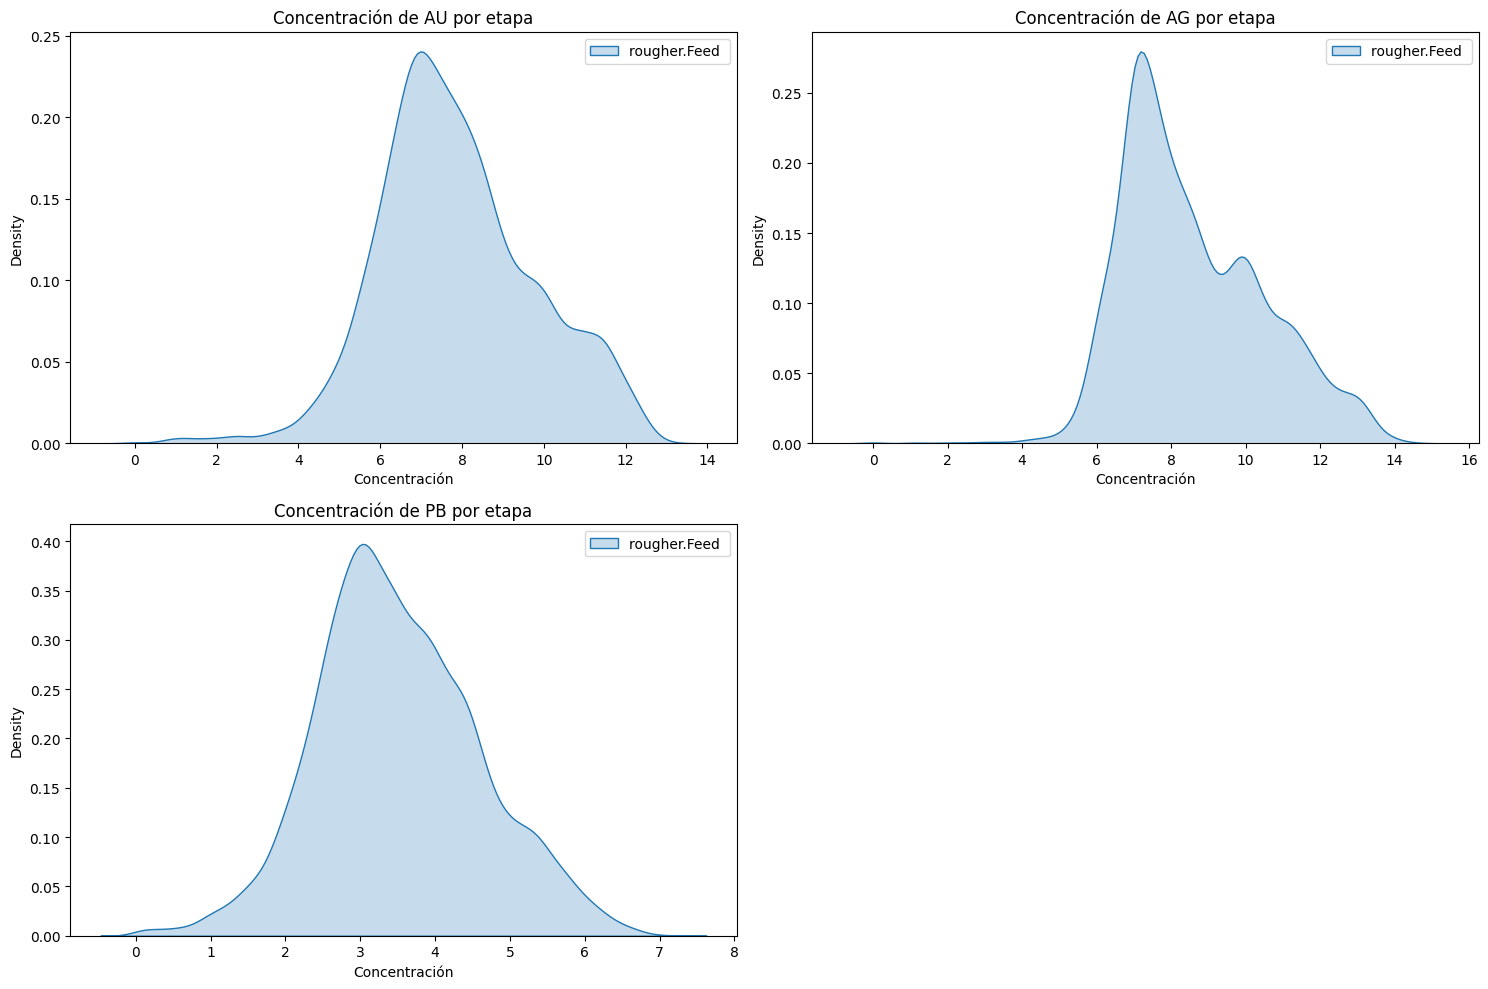

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

metals = ['au', 'ag', 'pb']
stages = ['rougher.input.feed_', 'rougher.output.concentrate_', 
          'primary_cleaner.output.concentrate_', 'final.output.concentrate_']

plt.figure(figsize=(15, 10))
for i, metal in enumerate(metals, 1):
    plt.subplot(2, 2, i)
    for stage in stages:
        col = stage + metal
        if col in train.columns:
            sns.kdeplot(train[col], label=stage.replace('.output.concentrate_','').replace('input.feed_','Feed '), fill=True)
    plt.title(f'Concentración de {metal.upper()} por etapa')
    plt.xlabel('Concentración')
    plt.legend()
plt.tight_layout()
plt.show()

## 2.2 Distribución del tamaño de partículas (feed size)

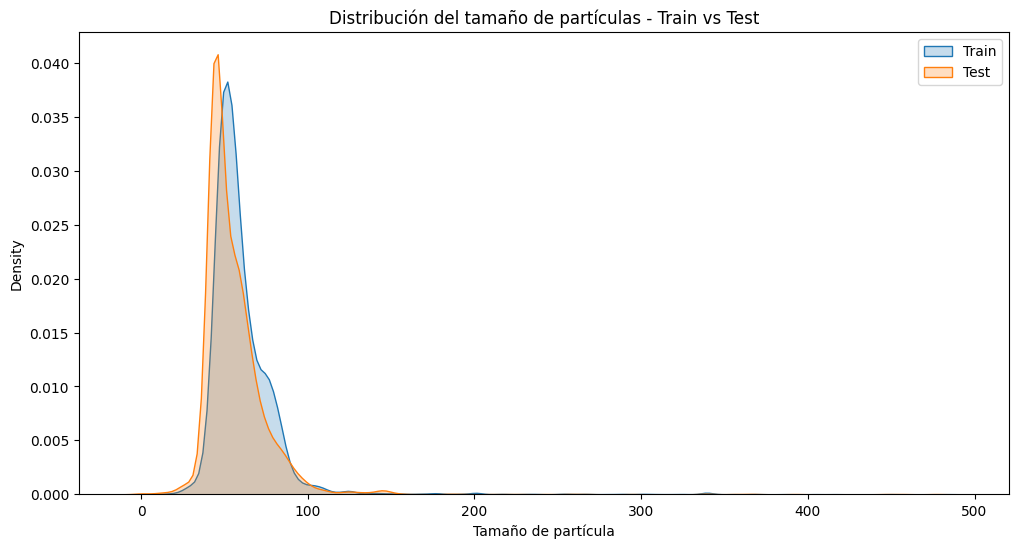

In [72]:
plt.figure(figsize=(12, 6))
sns.kdeplot(train['rougher.input.feed_size'], label='Train', fill=True)
sns.kdeplot(test['rougher.input.feed_size'], label='Test', fill=True)
plt.title('Distribución del tamaño de partículas - Train vs Test')
plt.xlabel('Tamaño de partícula')
plt.legend()
plt.show()

## 2.3 Concentración total de sustancias

In [76]:
# =============================================
# 2.3 CONCENTRACIÓN TOTAL - VERSIÓN CORREGIDA Y ROBUSTA
# =============================================

def total_concentration(df, stage):
    """Calcula la concentración total de Au, Ag, Pb y Sol"""
    # Buscamos columnas que contengan el stage y alguno de los metales
    metal_cols = [col for col in df.columns if 
                  stage in col and 
                  any(m in col.lower() for m in ['au', 'ag', 'pb', 'sol'])]
    return df[metal_cols].sum(axis=1)

# Calcular concentraciones totales
train_sum = total_concentration(train, 'rougher.input.feed')
train_sum_c = total_concentration(train, 'rougher.output.concentrate')
train_t = total_concentration(train, 'final.output.concentrate')

# Verificación de columnas encontradas
print("Columnas detectadas:")
print("Feed:   ", [col for col in train.columns if 'feed' in col and any(m in col for m in ['au','ag','pb','sol'])])
print("Rougher:", [col for col in train.columns if 'rougher.output.concentrate' in col and any(m in col for m in ['au','ag','pb','sol'])])
print("Final:  ", [col for col in train.columns if 'final.output.concentrate' in col and any(m in col for m in ['au','ag','pb','sol'])])

# Estadísticas
print("\n=== ESTADÍSTICAS ===")
for col in ['total_feed', 'total_rougher', 'total_final']:
    print(f"\n{col.upper()}:")
    print(f"  Mínimo: {train[col].min():.4f}")
    print(f"  Percentil 1%: {train[col].quantile(0.01):.4f}")
    print(f"  Percentil 5%: {train[col].quantile(0.05):.4f}")
    print(f"  Media: {train[col].mean():.4f}")
    print(f"  % ceros: {(train[col] == 0).mean()*100:.2f}%")

Columnas detectadas:
Feed:    ['rougher.input.feed_ag', 'rougher.input.feed_pb', 'rougher.input.feed_sol', 'rougher.input.feed_au']
Rougher: []
Final:   []

=== ESTADÍSTICAS ===

TOTAL_FEED:
  Mínimo: nan
  Percentil 1%: nan
  Percentil 5%: nan
  Media: nan
  % ceros: nan%

TOTAL_ROUGHER:
  Mínimo: nan
  Percentil 1%: nan
  Percentil 5%: nan
  Media: nan
  % ceros: nan%

TOTAL_FINAL:
  Mínimo: nan
  Percentil 1%: nan
  Percentil 5%: nan
  Media: nan
  % ceros: nan%


In [74]:
def total_concentration(df, stage_prefix):
    """Calcula la concentración total de Au + Ag + Pb + Sol"""
    cols = [col for col in df.columns if stage_prefix in col and 
            any(x in col for x in ['au', 'ag', 'pb', 'sol'])]
    return df[cols].sum(axis=1)

# Calcular concentraciones totales
train['total_feed'] = total_concentration(train, 'rougher.input.feed')
train['total_rougher'] = total_concentration(train, 'rougher.output.concentrate')
train['total_final'] = total_concentration(train, 'final.output.concentrate')

# === ANÁLISIS ANTES DE ELIMINAR ===
print("=== ANÁLISIS DE CONCENTRACIONES TOTALES ===")
print(f"Total de filas antes de filtrar: {len(train):,}")

for col in ['total_feed', 'total_rougher', 'total_final']:
    print(f"\n{col}:")
    print(f"  Mínimo: {train[col].min():.4f}")
    print(f"  Percentil 1%: {train[col].quantile(0.01):.4f}")
    print(f"  Percentil 5%: {train[col].quantile(0.05):.4f}")
    print(f"  Media: {train[col].mean():.4f}")

# === FILTRO SUAVIZADO (recomendado) ===
train_clean = train[
    (train['total_feed'] > 0.01) & 
    (train['total_rougher'] > 0.01) & 
    (train['total_final'] > 0.01)
].copy()

print(f"\nFilas después de eliminar anomalías: {len(train_clean):,}")
print(f"Filas eliminadas: {len(train) - len(train_clean):,} ({(len(train)-len(train_clean))/len(train)*100:.2f}%)")

# Actualizar el dataframe principal
train = train_clean

=== ANÁLISIS DE CONCENTRACIONES TOTALES ===
Total de filas antes de filtrar: 14,149

total_feed:
  Mínimo: 0.0400
  Percentil 1%: 33.9430
  Percentil 5%: 44.8128
  Media: 56.2422

total_rougher:
  Mínimo: 0.0000
  Percentil 1%: 0.0000
  Percentil 5%: 0.0000
  Media: 0.0000

total_final:
  Mínimo: 0.0000
  Percentil 1%: 0.0000
  Percentil 5%: 0.0000
  Media: 0.0000

Filas después de eliminar anomalías: 0
Filas eliminadas: 14,149 (100.00%)


# 3 Construimos el modelo

In [75]:
# Preparar features (ELIMINAR 'date')
features = list(test.columns)
features.remove('date')   # ← Muy importante

X_train = train[features]
y_train_rougher = train['rougher.output.recovery']
y_train_final = train['final.output.recovery']

X_test = test[features]

print(f"Features utilizadas para entrenar: {len(features)} columnas")

# Función sMAPE
def smape(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred) / ((np.abs(y_true) + np.abs(y_pred)) / 2)) * 100

def final_smape(smape_rougher, smape_final):
    return 0.25 * smape_rougher + 0.75 * smape_final

# Modelos
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("\n=== RESULTADOS DE VALIDACIÓN CRUZADA ===")
results = {}
print(X_train, y_train_rougher)
for name, model in models.items():
    # Rougher
    scores_rougher = cross_val_score(model, X_train, y_train_rougher, 
                                     cv=kf, scoring='neg_mean_absolute_error', error_score='raise')
    smape_rougher_cv = -scores_rougher.mean()
    
    # Final
    scores_final = cross_val_score(model, X_train, y_train_final, 
                                   cv=kf, scoring='neg_mean_absolute_error', error_score='raise')
    smape_final_cv = -scores_final.mean()
    
    final_score = final_smape(smape_rougher_cv, smape_final_cv)
    
    results[name] = final_score
    print(f"{name:20} → sMAPE Final: {final_score:.4f}")

# Mejor modelo
best_model_name = min(results, key=results.get)
print(f"\n✅ Mejor modelo: {best_model_name} con sMAPE = {results[best_model_name]:.4f}")

Features utilizadas para entrenar: 52 columnas

=== RESULTADOS DE VALIDACIÓN CRUZADA ===
Empty DataFrame
Columns: [primary_cleaner.input.sulfate, primary_cleaner.input.depressant, primary_cleaner.input.feed_size, primary_cleaner.input.xanthate, primary_cleaner.state.floatbank8_a_air, primary_cleaner.state.floatbank8_a_level, primary_cleaner.state.floatbank8_b_air, primary_cleaner.state.floatbank8_b_level, primary_cleaner.state.floatbank8_c_air, primary_cleaner.state.floatbank8_c_level, primary_cleaner.state.floatbank8_d_air, primary_cleaner.state.floatbank8_d_level, rougher.input.feed_ag, rougher.input.feed_pb, rougher.input.feed_rate, rougher.input.feed_size, rougher.input.feed_sol, rougher.input.feed_au, rougher.input.floatbank10_sulfate, rougher.input.floatbank10_xanthate, rougher.input.floatbank11_sulfate, rougher.input.floatbank11_xanthate, rougher.state.floatbank10_a_air, rougher.state.floatbank10_a_level, rougher.state.floatbank10_b_air, rougher.state.floatbank10_b_level, roughe

ValueError: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=0.

# ENTRENAMIENTO FINAL Y PREDICCIÓN EN TEST

In [ ]:
best_model = models[best_model_name]

# Entrenar dos modelos (uno para rougher y otro para final)
model_rougher = best_model
model_final = best_model.copy() if hasattr(best_model, 'copy') else type(best_model)(**best_model.get_params())

model_rougher.fit(X_train, y_train_rougher)
model_final.fit(X_train, y_train_final)

# Predicciones
test['rougher.output.recovery'] = model_rougher.predict(X_test)
test['final.output.recovery'] = model_final.predict(X_test)

print("\n=== PREDICCIONES EN TEST COMPLETADAS ===")
print(test[['date', 'rougher.output.recovery', 'final.output.recovery']].head())

# Resultados finales
print(f"\n✅ Proyecto completado. Mejor sMAPE en validación cruzada: {results[best_model_name]:.4f}")